In [1]:
import polars as pl

# Book dataset

In [2]:
books_df = pl.scan_ndjson(r"C:\Users\vojta\Downloads\goodreads_books_fantasy_paranormal.json\goodreads_books_fantasy_paranormal.json")

In [3]:
books_df = books_df.with_columns(
    pl.col("text_reviews_count").cast(pl.Int32, strict=False),
    pl.col("average_rating").cast(pl.Float32, strict=False),
    pl.col("num_pages").cast(pl.Int32, strict=False),
    pl.col("publication_day").cast(pl.Int8, strict=False),
    pl.col("publication_month").cast(pl.Int8, strict=False),
    pl.col("publication_year").cast(pl.Int32, strict=False),
    pl.col("book_id").cast(pl.Int64, strict=False),
    pl.col("ratings_count").cast(pl.Int32, strict=False),
    pl.col("work_id").cast(pl.Int64, strict=False)
)

In [4]:
books_df.count().show()

isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,similar_books,description,format,link,authors,publisher,num_pages,publication_day,isbn13,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
258585,258585,258585,258585,258585,258585,258585,258585,258585,258585,258585,258585,258585,258585,258585,258585,176344,160499,258585,176444,258585,196074,258585,258585,258585,258585,258585,258585,258585


In [5]:
books_df = books_df.filter(pl.col('ratings_count') > 10)
books_df.count().show()

isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,similar_books,description,format,link,authors,publisher,num_pages,publication_day,isbn13,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
204482,204482,204482,204482,204482,204482,204482,204482,204482,204482,204482,204482,204482,204482,204482,204482,145161,129382,204482,141498,204482,155363,204482,204482,204482,204482,204482,204482,204482


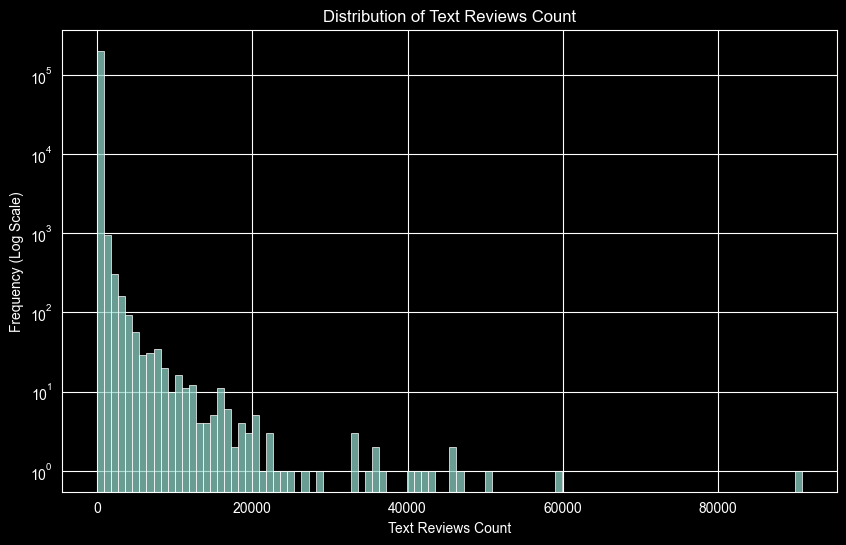

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
text_reviews = books_df.select("text_reviews_count").drop_nulls().collect().to_pandas()

plt.figure(figsize=(10, 6))
sns.histplot(data=text_reviews, x="text_reviews_count", bins=100)
plt.yscale("log")
plt.title("Distribution of Text Reviews Count")
plt.xlabel("Text Reviews Count")
plt.ylabel("Frequency (Log Scale)")
plt.show()

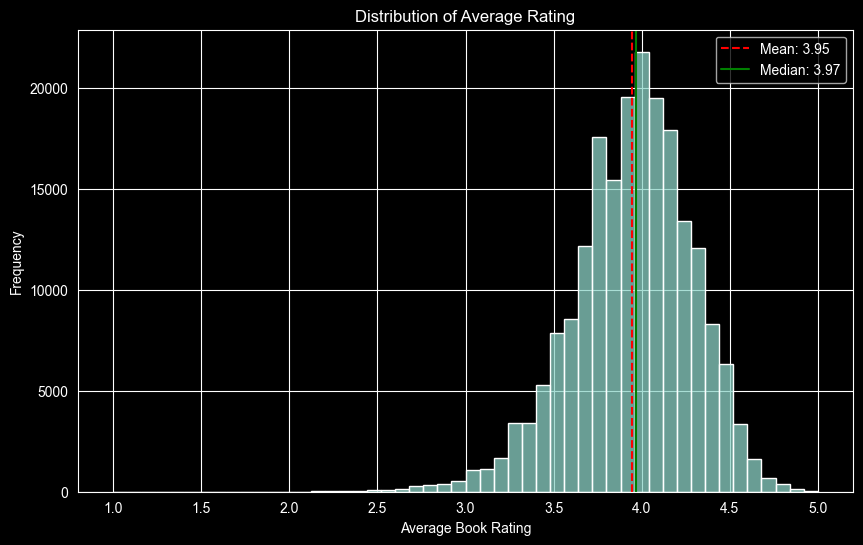

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

text_reviews = books_df.select("average_rating").drop_nulls().collect().to_pandas()

mean_rating = text_reviews["average_rating"].mean()
median_rating = text_reviews["average_rating"].median()

plt.figure(figsize=(10, 6))
sns.histplot(data=text_reviews, x="average_rating", bins=50)
plt.axvline(mean_rating, color='red', linestyle='--', label=f'Mean: {mean_rating:.2f}')
plt.axvline(median_rating, color='green', linestyle='-', label=f'Median: {median_rating:.2f}')
# plt.yscale("log")
plt.title("Distribution of Average Rating")
plt.xlabel("Average Book Rating")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Interactions dataset

In [8]:
interactions_df = pl.scan_ndjson(r"C:\Users\vojta\Downloads\goodreads_interactions_fantasy_paranormal.json\goodreads_interactions_fantasy_paranormal.json")

In [9]:
interactions_df.head().show()

user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
str,str,str,bool,i64,str,str,str,str,str
"""8842281e1d1347389f2ab93d60773d…","""19161852""","""4443cb6883624c3772625ef5b7b4e1…",false,0,"""""","""Fri Sep 08 10:44:24 -0700 2017""","""Fri Sep 08 10:44:24 -0700 2017""","""""",""""""
"""8842281e1d1347389f2ab93d60773d…","""18245960""","""dfdbb7b0eb5a7e4c26d59a937e2e5f…",true,5,"""This is a special book. It sta…","""Sun Jul 30 07:44:10 -0700 2017""","""Wed Aug 30 00:00:26 -0700 2017""","""Sat Aug 26 12:05:52 -0700 2017""","""Tue Aug 15 13:23:18 -0700 2017"""
"""8842281e1d1347389f2ab93d60773d…","""32075825""","""11ffeb4204d7421f716a8f91c190ef…",false,0,"""""","""Wed May 31 06:41:50 -0700 2017""","""Wed May 31 06:41:51 -0700 2017""","""""",""""""
"""8842281e1d1347389f2ab93d60773d…","""43615""","""07ab7d654e3c84769e5eb8e5cabd5e…",false,0,"""""","""Mon Apr 03 13:27:29 -0700 2017""","""Mon Apr 03 13:27:30 -0700 2017""","""""",""""""
"""8842281e1d1347389f2ab93d60773d…","""26721984""","""90b82c8d8e8a514b5fd1e4568075e0…",false,0,"""""","""Wed Mar 29 00:28:30 -0700 2017""","""Wed Mar 29 00:28:31 -0700 2017""","""""",""""""


In [10]:
interactions_df = interactions_df.filter(
    (pl.col('rating') > 0) &
    (pl.col('is_read') == True) &
    (pl.col('read_at').is_not_null()) &
    (pl.col('read_at') != "")
)
interactions_df.collect().show()


user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
str,str,str,bool,i64,str,str,str,str,str
"""8842281e1d1347389f2ab93d60773d…","""18245960""","""dfdbb7b0eb5a7e4c26d59a937e2e5f…",true,5,"""This is a special book. It sta…","""Sun Jul 30 07:44:10 -0700 2017""","""Wed Aug 30 00:00:26 -0700 2017""","""Sat Aug 26 12:05:52 -0700 2017""","""Tue Aug 15 13:23:18 -0700 2017"""
"""8842281e1d1347389f2ab93d60773d…","""29058155""","""3759ba2b18dd09eb5e844a116f0ce0…",true,3,"""""","""Mon Jul 25 14:29:33 -0700 2016""","""Tue Dec 13 11:00:02 -0800 2016""","""Sat Aug 20 00:00:00 -0700 2016""","""Wed Aug 17 00:00:00 -0700 2016"""
"""8842281e1d1347389f2ab93d60773d…","""5577844""","""52c8ac49496c153e4a97161e36b2db…",true,5,"""A beautiful story. Neil Gaiman…","""Wed Sep 24 09:29:29 -0700 2014""","""Wed Oct 01 00:31:56 -0700 2014""","""Tue Sep 30 00:00:00 -0700 2014""","""Sun Sep 21 00:00:00 -0700 2014"""
"""8842281e1d1347389f2ab93d60773d…","""17315048""","""885c772fb033b041f42d57cef5be0a…",true,5,"""Mark Watney is a steely-eyed m…","""Sat Apr 05 09:30:53 -0700 2014""","""Wed Mar 22 11:33:10 -0700 2017""","""Mon Aug 25 00:00:00 -0700 2014""","""Sat Aug 16 00:00:00 -0700 2014"""
"""8842281e1d1347389f2ab93d60773d…","""13453029""","""46a6e1a14e8afc82d221fec0a2bd3d…",true,4,"""A fun fast paced book that suc…","""Tue Dec 04 11:12:22 -0800 2012""","""Sat Jul 26 11:43:28 -0700 2014""","""Tue Jul 08 00:00:00 -0700 2014""","""Wed Jul 02 00:00:00 -0700 2014"""


In [11]:
# Iterative K-core filtering: Remove users and books with fewer than 10 ratings until convergence.
eager_interactions = interactions_df.collect()

k = 10
iteration = 1
while True:
    original_rows = eager_interactions.shape[0]

    # Drop users with < k ratings
    user_counts = eager_interactions.group_by("user_id").agg(pl.col("rating").count().alias("user_count"))
    eager_interactions = eager_interactions.join(user_counts, on="user_id").filter(pl.col("user_count") >= k).drop("user_count")

    # Drop books with < k ratings
    book_counts = eager_interactions.group_by("book_id").agg(pl.col("rating").count().alias("book_count"))
    eager_interactions = eager_interactions.join(book_counts, on="book_id").filter(pl.col("book_count") >= k).drop("book_count")

    new_rows = eager_interactions.shape[0]
    print(f"Iteration {iteration}: {original_rows} -> {new_rows} interactions")

    if original_rows == new_rows:
        print("Convergence reached.")
        break
    iteration += 1

interactions_df = eager_interactions.lazy()

print("After iterative K-core filtering:")
interactions_df.collect().show()




Iteration 1: 10207249 -> 8833928 interactions
Iteration 2: 8833928 -> 8788444 interactions
Iteration 3: 8788444 -> 8785863 interactions
Iteration 4: 8785863 -> 8785449 interactions
Iteration 5: 8785449 -> 8785377 interactions
Iteration 6: 8785377 -> 8785359 interactions
Iteration 7: 8785359 -> 8785359 interactions
Convergence reached.
After iterative K-core filtering:


user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
str,str,str,bool,i64,str,str,str,str,str
"""8842281e1d1347389f2ab93d60773d…","""18245960""","""dfdbb7b0eb5a7e4c26d59a937e2e5f…",true,5,"""This is a special book. It sta…","""Sun Jul 30 07:44:10 -0700 2017""","""Wed Aug 30 00:00:26 -0700 2017""","""Sat Aug 26 12:05:52 -0700 2017""","""Tue Aug 15 13:23:18 -0700 2017"""
"""8842281e1d1347389f2ab93d60773d…","""29058155""","""3759ba2b18dd09eb5e844a116f0ce0…",true,3,"""""","""Mon Jul 25 14:29:33 -0700 2016""","""Tue Dec 13 11:00:02 -0800 2016""","""Sat Aug 20 00:00:00 -0700 2016""","""Wed Aug 17 00:00:00 -0700 2016"""
"""8842281e1d1347389f2ab93d60773d…","""5577844""","""52c8ac49496c153e4a97161e36b2db…",true,5,"""A beautiful story. Neil Gaiman…","""Wed Sep 24 09:29:29 -0700 2014""","""Wed Oct 01 00:31:56 -0700 2014""","""Tue Sep 30 00:00:00 -0700 2014""","""Sun Sep 21 00:00:00 -0700 2014"""
"""8842281e1d1347389f2ab93d60773d…","""17315048""","""885c772fb033b041f42d57cef5be0a…",true,5,"""Mark Watney is a steely-eyed m…","""Sat Apr 05 09:30:53 -0700 2014""","""Wed Mar 22 11:33:10 -0700 2017""","""Mon Aug 25 00:00:00 -0700 2014""","""Sat Aug 16 00:00:00 -0700 2014"""
"""8842281e1d1347389f2ab93d60773d…","""13453029""","""46a6e1a14e8afc82d221fec0a2bd3d…",true,4,"""A fun fast paced book that suc…","""Tue Dec 04 11:12:22 -0800 2012""","""Sat Jul 26 11:43:28 -0700 2014""","""Tue Jul 08 00:00:00 -0700 2014""","""Wed Jul 02 00:00:00 -0700 2014"""


Investigate the number of user reviews.

The Goodreads dataset was collected in 2017 (per authors), while Goodreads was created in December 2006 (per Wikipedia). Given some rounding erros, that makes around 4000 days. It would make sense to remove some clearly botted accounts that read more than 1 book in a few days.

In [12]:
interactions_per_user = interactions_df.group_by("user_id").agg(pl.col("book_id").count().alias("interaction_count"))

metrics = interactions_per_user.select([
    pl.col("user_id").count().alias("unique_users"),
    pl.col("interaction_count").mean().alias("avg_interactions"),
    pl.col("interaction_count").median().alias("median_interactions"),
]).collect()

print(f"Number of unique users: {metrics.get_column('unique_users')[0]}")
print(f"Average number of interactions per user: {metrics.get_column('avg_interactions')[0]:.2f}")
print(f"Median number of interactions per user: {metrics.get_column('median_interactions')[0]:.2f}")



Number of unique users: 165617
Average number of interactions per user: 53.05
Median number of interactions per user: 28.00


C:\Users\vojta\AppData\Local\Temp\ipykernel_35280\1353705321.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


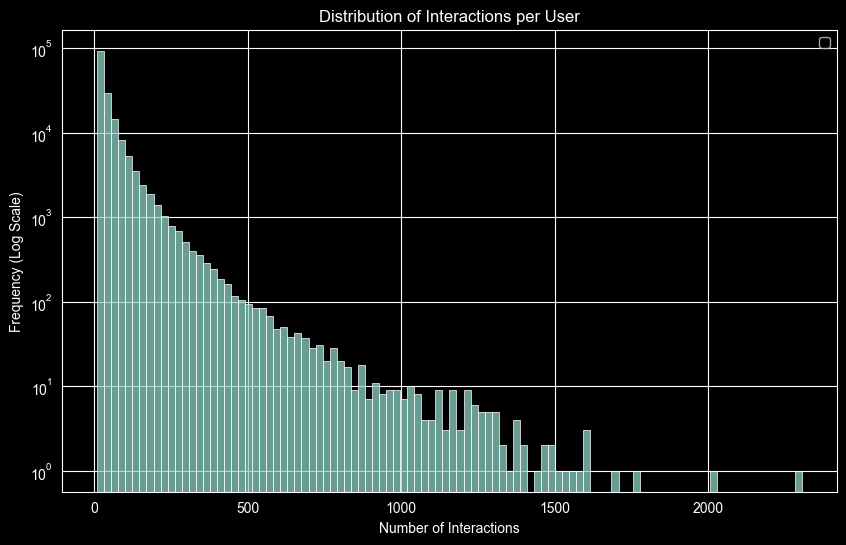

In [13]:
interactions_counts_pd = interactions_per_user.select("interaction_count").collect().to_pandas()


plt.figure(figsize=(10, 6))
sns.histplot(data=interactions_counts_pd, x="interaction_count", bins=100)
plt.yscale("log")
plt.title("Distribution of Interactions per User")
plt.xlabel("Number of Interactions")
plt.ylabel("Frequency (Log Scale)")
plt.legend()
plt.show()


In [14]:
# Remove users with more than 1000 interactions (reviews)
valid_users = interactions_per_user.filter(pl.col("interaction_count") <= 1000).select("user_id")
interactions_df = interactions_df.join(valid_users, on="user_id", how="inner")

print("After removing users with > 1000 interactions:")
interactions_df.collect().show()


After removing users with > 1000 interactions:


user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
str,str,str,bool,i64,str,str,str,str,str
"""8842281e1d1347389f2ab93d60773d…","""18245960""","""dfdbb7b0eb5a7e4c26d59a937e2e5f…",true,5,"""This is a special book. It sta…","""Sun Jul 30 07:44:10 -0700 2017""","""Wed Aug 30 00:00:26 -0700 2017""","""Sat Aug 26 12:05:52 -0700 2017""","""Tue Aug 15 13:23:18 -0700 2017"""
"""8842281e1d1347389f2ab93d60773d…","""29058155""","""3759ba2b18dd09eb5e844a116f0ce0…",true,3,"""""","""Mon Jul 25 14:29:33 -0700 2016""","""Tue Dec 13 11:00:02 -0800 2016""","""Sat Aug 20 00:00:00 -0700 2016""","""Wed Aug 17 00:00:00 -0700 2016"""
"""8842281e1d1347389f2ab93d60773d…","""5577844""","""52c8ac49496c153e4a97161e36b2db…",true,5,"""A beautiful story. Neil Gaiman…","""Wed Sep 24 09:29:29 -0700 2014""","""Wed Oct 01 00:31:56 -0700 2014""","""Tue Sep 30 00:00:00 -0700 2014""","""Sun Sep 21 00:00:00 -0700 2014"""
"""8842281e1d1347389f2ab93d60773d…","""17315048""","""885c772fb033b041f42d57cef5be0a…",true,5,"""Mark Watney is a steely-eyed m…","""Sat Apr 05 09:30:53 -0700 2014""","""Wed Mar 22 11:33:10 -0700 2017""","""Mon Aug 25 00:00:00 -0700 2014""","""Sat Aug 16 00:00:00 -0700 2014"""
"""8842281e1d1347389f2ab93d60773d…","""13453029""","""46a6e1a14e8afc82d221fec0a2bd3d…",true,4,"""A fun fast paced book that suc…","""Tue Dec 04 11:12:22 -0800 2012""","""Sat Jul 26 11:43:28 -0700 2014""","""Tue Jul 08 00:00:00 -0700 2014""","""Wed Jul 02 00:00:00 -0700 2014"""


Average rating across all users: 4.02


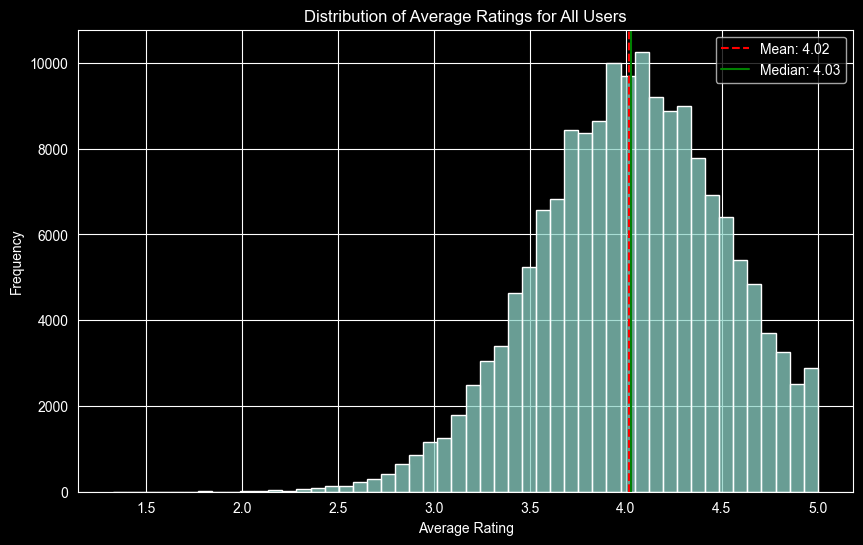

In [15]:
# Calculate the average rating for all users (after dropping power users)
all_users_avg_ratings = interactions_df.group_by("user_id").agg(
    pl.col("rating").mean().alias("avg_rating")
).collect().to_pandas()

mean_all_rating = all_users_avg_ratings["avg_rating"].mean()
median_all_rating = all_users_avg_ratings["avg_rating"].median()

print(f"Average rating across all users: {mean_all_rating:.2f}")

plt.figure(figsize=(10, 6))
sns.histplot(data=all_users_avg_ratings, x="avg_rating", bins=50)
plt.axvline(mean_all_rating, color='red', linestyle='--', label=f'Mean: {mean_all_rating:.2f}')
plt.axvline(median_all_rating, color='green', linestyle='-', label=f'Median: {median_all_rating:.2f}')
plt.title("Distribution of Average Ratings for All Users")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.legend()
plt.show()


### Variance Analysis
Users with a rating variance of 0 (or near 0) give the exact same rating to every book they read. We can visualize this and filter them out.

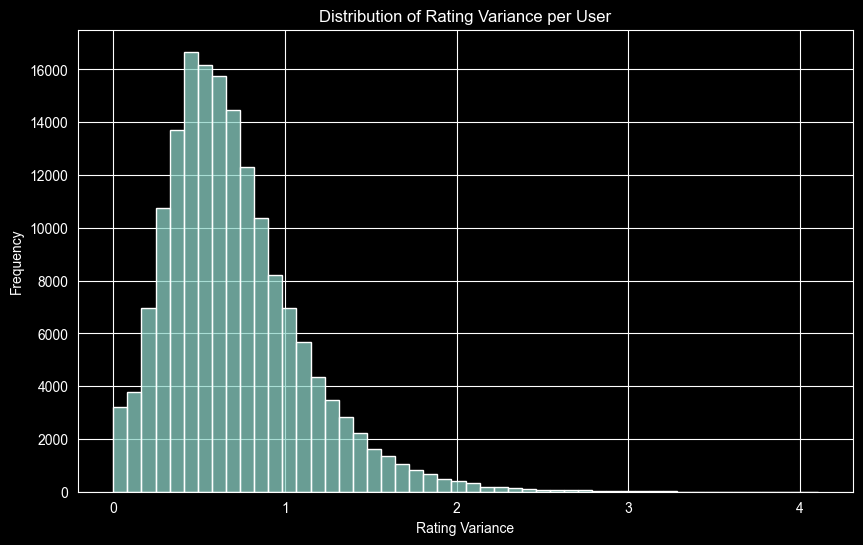

In [16]:
# Calculate the variance of ratings per user
user_variances = interactions_df.group_by("user_id").agg(
    pl.col("rating").var().alias("rating_variance")
).fill_null(0.0)

user_variances_pd = user_variances.select("rating_variance").collect().to_pandas()

plt.figure(figsize=(10, 6))
sns.histplot(data=user_variances_pd, x="rating_variance", bins=50)
plt.title("Distribution of Rating Variance per User")
plt.xlabel("Rating Variance")
plt.ylabel("Frequency")
plt.show()


In [17]:
# Count users with zero variance (or practically zero)
zero_variance_users = user_variances.filter(pl.col("rating_variance") == 0.0)
zero_variance_count = zero_variance_users.select(pl.len()).collect().item()

print(f"Number of users with exactly 0.0 variance: {zero_variance_count}")

# Filter out users with 0 variance from interactions_df
interactions_df = interactions_df.join(
    user_variances.filter(pl.col("rating_variance") > 0.0).select("user_id"),
    on="user_id",
    how="inner"
)

print("After removing users with zero variance:")
interactions_df.collect().show()


Number of users with exactly 0.0 variance: 1773
After removing users with zero variance:


user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
str,str,str,bool,i64,str,str,str,str,str
"""8842281e1d1347389f2ab93d60773d…","""18245960""","""dfdbb7b0eb5a7e4c26d59a937e2e5f…",true,5,"""This is a special book. It sta…","""Sun Jul 30 07:44:10 -0700 2017""","""Wed Aug 30 00:00:26 -0700 2017""","""Sat Aug 26 12:05:52 -0700 2017""","""Tue Aug 15 13:23:18 -0700 2017"""
"""8842281e1d1347389f2ab93d60773d…","""29058155""","""3759ba2b18dd09eb5e844a116f0ce0…",true,3,"""""","""Mon Jul 25 14:29:33 -0700 2016""","""Tue Dec 13 11:00:02 -0800 2016""","""Sat Aug 20 00:00:00 -0700 2016""","""Wed Aug 17 00:00:00 -0700 2016"""
"""8842281e1d1347389f2ab93d60773d…","""5577844""","""52c8ac49496c153e4a97161e36b2db…",true,5,"""A beautiful story. Neil Gaiman…","""Wed Sep 24 09:29:29 -0700 2014""","""Wed Oct 01 00:31:56 -0700 2014""","""Tue Sep 30 00:00:00 -0700 2014""","""Sun Sep 21 00:00:00 -0700 2014"""
"""8842281e1d1347389f2ab93d60773d…","""17315048""","""885c772fb033b041f42d57cef5be0a…",true,5,"""Mark Watney is a steely-eyed m…","""Sat Apr 05 09:30:53 -0700 2014""","""Wed Mar 22 11:33:10 -0700 2017""","""Mon Aug 25 00:00:00 -0700 2014""","""Sat Aug 16 00:00:00 -0700 2014"""
"""8842281e1d1347389f2ab93d60773d…","""13453029""","""46a6e1a14e8afc82d221fec0a2bd3d…",true,4,"""A fun fast paced book that suc…","""Tue Dec 04 11:12:22 -0800 2012""","""Sat Jul 26 11:43:28 -0700 2014""","""Tue Jul 08 00:00:00 -0700 2014""","""Wed Jul 02 00:00:00 -0700 2014"""


In [18]:
interactions_df = interactions_df.select([
    "user_id",
    "book_id",
    "rating",
    "read_at"
])

print("Final interactions dataframe:")
interactions_df.collect().show()


Final interactions dataframe:


user_id,book_id,rating,read_at
str,str,i64,str
"""8842281e1d1347389f2ab93d60773d…","""18245960""",5,"""Sat Aug 26 12:05:52 -0700 2017"""
"""8842281e1d1347389f2ab93d60773d…","""29058155""",3,"""Sat Aug 20 00:00:00 -0700 2016"""
"""8842281e1d1347389f2ab93d60773d…","""5577844""",5,"""Tue Sep 30 00:00:00 -0700 2014"""
"""8842281e1d1347389f2ab93d60773d…","""17315048""",5,"""Mon Aug 25 00:00:00 -0700 2014"""
"""8842281e1d1347389f2ab93d60773d…","""13453029""",4,"""Tue Jul 08 00:00:00 -0700 2014"""


### Save Cleaned Datasets

In [19]:
import os
os.makedirs("../processed-data", exist_ok=True)

# Parse the datetime string and create a proper datetime column
eager_final = interactions_df.collect()

eager_final = eager_final.with_columns(
    pl.col("read_at").str.strptime(
        pl.Datetime,
        format="%a %b %d %H:%M:%S %z %Y",
        strict=False
    ).alias("parsed_date")
)

# Sort by user and date
eager_final = eager_final.sort(["user_id", "parsed_date"])

# Create a row number for each user's interactions and total count
eager_final = eager_final.with_columns(
    pl.col("parsed_date").cum_count().over("user_id").alias("row_num"),
    pl.col("parsed_date").count().over("user_id").alias("total_inter")
)

# Time-aware split: last 20% of interactions per user go to test set
train_df = eager_final.filter(pl.col("row_num") <= (pl.col("total_inter") * 0.8))
test_df = eager_final.filter(pl.col("row_num") > (pl.col("total_inter") * 0.8))

# Drop temporary columns
train_df = train_df.drop(["parsed_date", "row_num", "total_inter"])
test_df = test_df.drop(["parsed_date", "row_num", "total_inter"])

print(f"Train set size: {train_df.shape[0]}")
print(f"Test set size: {test_df.shape[0]}")

train_df.write_ndjson("../processed-data/train_interactions_fantasy_paranormal.json")
test_df.write_ndjson("../processed-data/test_interactions_fantasy_paranormal.json")

eager_final.drop(["parsed_date", "row_num", "total_inter"]).write_ndjson("../processed-data/cleaned_interactions_fantasy_paranormal.json")
books_df.collect().write_ndjson("../processed-data/cleaned_books_fantasy_paranormal.json")

print("Datasets successfully saved!")


Train set size: 6821766
Test set size: 1786728
Datasets successfully saved!
